In [2]:
import pandas as pd
import numpy as np

In [25]:
train = pd.read_csv('train_model.csv')


In [27]:
train_cluster1 = train[train['Cluster'] == 1]
train_cluster1 = train_cluster1.fillna(0)
train_cluster1["Log_sales"] = np.log(1+train_cluster1["Sales"])

In [28]:
# Apply square root transformation to the "Sales" column
train_cluster1['Sqrt_sales'] = np.sqrt(train_cluster1['Sales'])
train_cluster1=train_cluster1.fillna(0)
train_cluster1["Log_dist"] = np.log(1+train_cluster1["CompetitionDistanceKM"])

In [29]:
train_cluster1['Promo'].unique()

array([0, 1], dtype=int64)

In [30]:
# Assuming your DataFrame is named 'df' and contains columns 'Year', 'Month', and 'Day'
train_cluster1['Date'] = pd.to_datetime(train_cluster1['Date'])
# Set the 'Date' column as the index
train_cluster1.set_index('Date', inplace=True)


In [31]:
train_cluster1.columns

Index(['Unnamed: 0', 'Store', 'DayOfWeek', 'Sales', 'Customers', 'Open',
       'Promo', 'SchoolHoliday', 'CompetitionDistance',
       'CompetitionDistanceKM', 'DistanceCategory',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
       'CompetitionOpenSinceYear.1', 'WeeksSinceLastCompOpen',
       'MonthsSinceLastCompOpen', 'YearsSinceLastCompOpen', 'Promo2',
       'PromoInterval', 'WeeksSinceLastPromo', 'MonthsSinceLastPromo',
       'YearsSinceLastPromo', 'LastCouponSend', 'DaysSinceCoupon', 'Cluster',
       'Assortment_a', 'Assortment_b', 'Assortment_c', 'StoreType_a',
       'StoreType_b', 'StoreType_c', 'StoreType_d', 'StateHoliday_0',
       'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c', 'Log_sales',
       'Sqrt_sales', 'Log_dist'],
      dtype='object')

In [32]:
train_cluster1 = train_cluster1.drop(columns = ['Unnamed: 0'])

C:\Users\PC\anaconda3\Lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


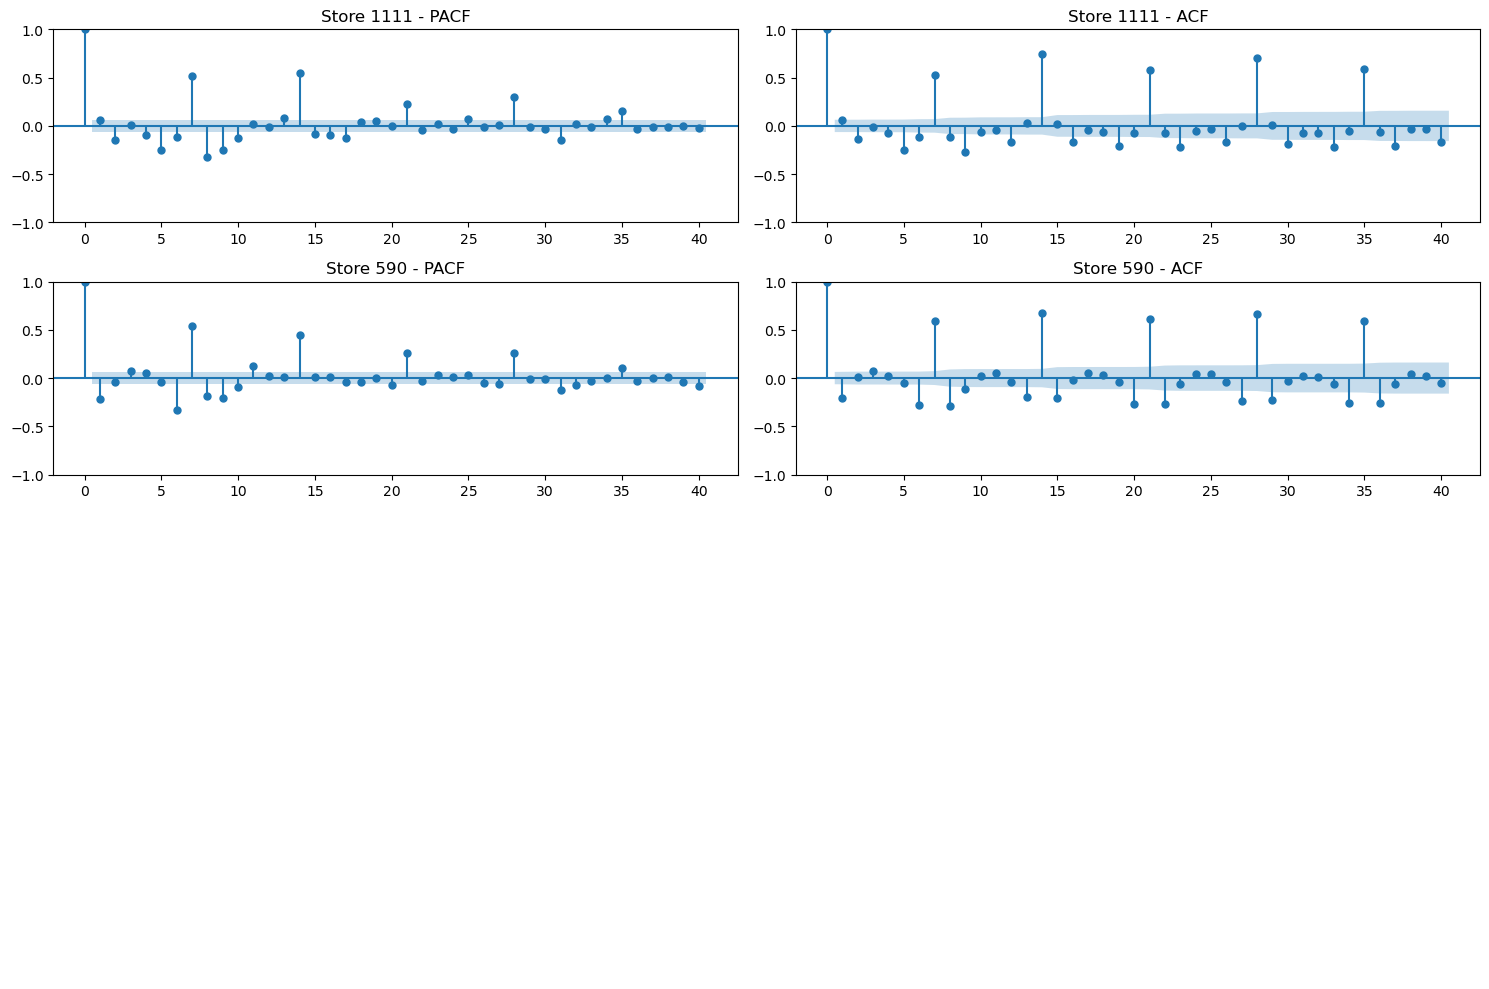

In [33]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Step 1: Select 2 random stores
random_stores = np.random.choice(train_cluster1['Store'].unique(), size=2, replace=False)

# Step 2: Extract sales data for the random stores
sales_store1 = train_cluster1[train_cluster1['Store'] == random_stores[0]]['Sales']
sales_store2 = train_cluster1[train_cluster1['Store'] == random_stores[1]]['Sales']

# Step 3: Plot PACF and ACF for each store
fig, axes = plt.subplots(4, 2, figsize=(15, 10))

# PACF for store 1
sm.graphics.tsa.plot_pacf(sales_store1, lags=40, ax=axes[0, 0])
axes[0, 0].set_title(f'Store {random_stores[0]} - PACF')

# ACF for store 1
sm.graphics.tsa.plot_acf(sales_store1, lags=40, ax=axes[0, 1])
axes[0, 1].set_title(f'Store {random_stores[0]} - ACF')

# PACF for store 2
sm.graphics.tsa.plot_pacf(sales_store2, lags=40, ax=axes[1, 0])
axes[1, 0].set_title(f'Store {random_stores[1]} - PACF')

# ACF for store 2
sm.graphics.tsa.plot_acf(sales_store2, lags=40, ax=axes[1, 1])
axes[1, 1].set_title(f'Store {random_stores[1]} - ACF')

# Hide remaining subplots
for ax in axes[2:].flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
#Sales are correlated with sales from 1 week ago

C:\Users\PC\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Step 1: Select 2 random stores
random_stores = np.random.choice(train_cluster0['Store'].unique(), size=2, replace=False)

# Step 2: Extract sales data for the random stores
sales_store1 = train_cluster0[train_cluster0['Store'] == random_stores[0]]['Log_sales']
sales_store2 = train_cluster0[train_cluster0['Store'] == random_stores[1]]['Log_sales']

# Step 3: Decompose sales data
decomposition_store1 = seasonal_decompose(sales_store1, model='additive', period=365)  # Assuming yearly seasonality
decomposition_store2 = seasonal_decompose(sales_store2, model='additive', period=365)

# Step 4: Run ADF test for residual component
adf_result_store1 = adfuller(decomposition_store1.resid.dropna())
adf_result_store2 = adfuller(decomposition_store2.resid.dropna())

# Print ADF test results
print(f'ADF test results for Store {random_stores[0]} - p-value: {adf_result_store1[1]}')
print(f'ADF test results for Store {random_stores[1]} - p-value: {adf_result_store2[1]}')

ADF test results for Store 246 - p-value: 1.164560066097356e-05
ADF test results for Store 985 - p-value: 1.5107388522327986e-05


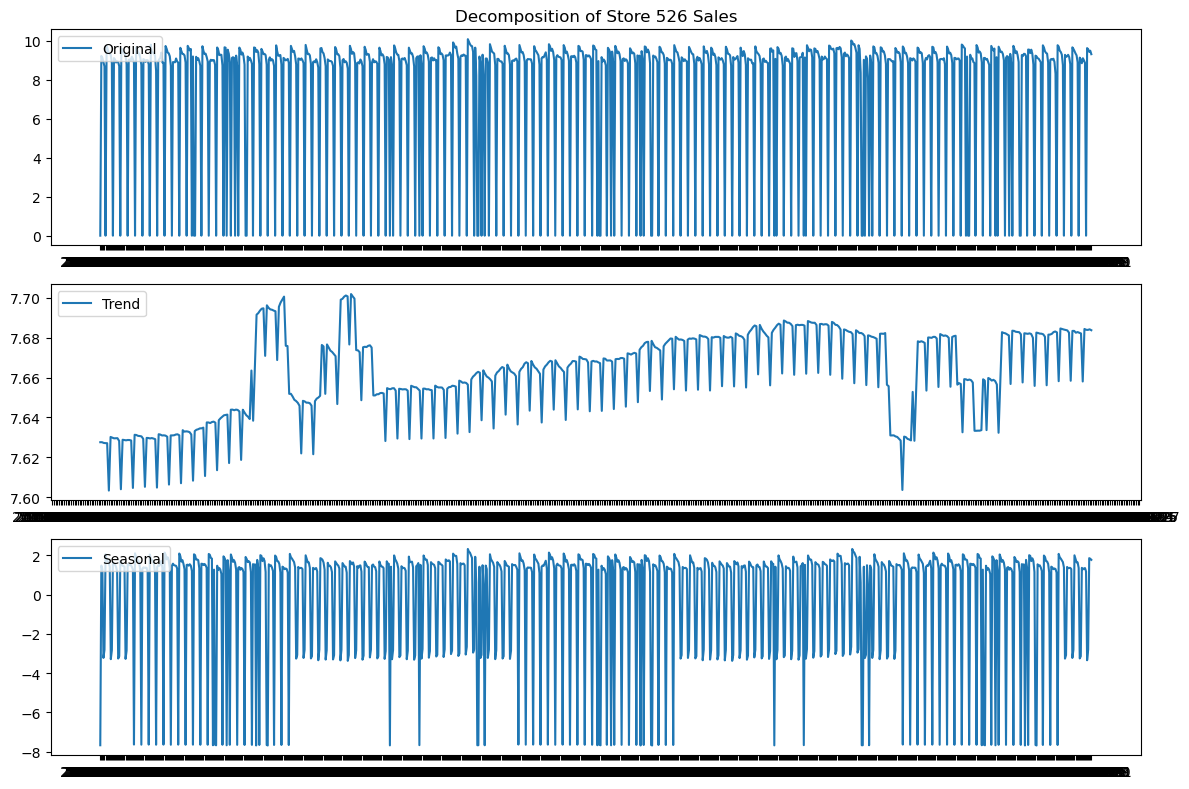

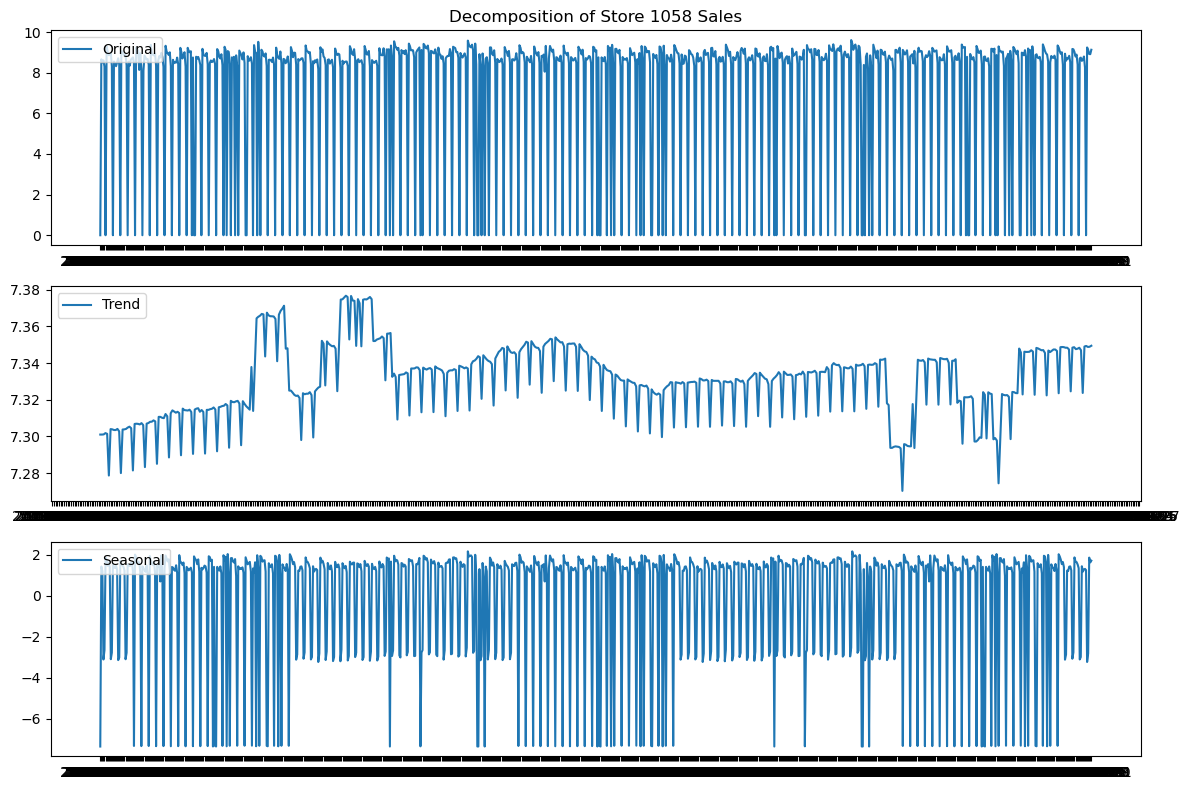

In [148]:
import matplotlib.pyplot as plt

# Plot decomposition for store 1
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(sales_store1, label='Original')
plt.legend(loc='upper left')
plt.title(f'Decomposition of Store {random_stores[0]} Sales')
plt.subplot(3, 1, 2)
plt.plot(decomposition_store1.trend, label='Trend')
plt.legend(loc='upper left')
plt.subplot(3, 1, 3)
plt.plot(decomposition_store1.seasonal, label='Seasonal')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Plot decomposition for store 2
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(sales_store2, label='Original')
plt.legend(loc='upper left')
plt.title(f'Decomposition of Store {random_stores[1]} Sales')
plt.subplot(3, 1, 2)
plt.plot(decomposition_store2.trend, label='Trend')
plt.legend(loc='upper left')
plt.subplot(3, 1, 3)
plt.plot(decomposition_store2.seasonal, label='Seasonal')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
#Stationary

In [34]:
#Add lagged sales
# Define the lagged sales intervals (every 7 days)
lag_intervals = [7, 14, 21, 28, 35, 42, 49, 56, 63, 70]  # Add more intervals as needed

# Iterate over unique store IDs
for store_id in train_cluster1['Store'].unique():
    # Filter data for the current product and store
    condition = (train_cluster1['Store'] == store_id)
    subset = train_cluster1.loc[condition].copy()
        
    # Skip empty subsets
    if subset.empty:
        continue

    # Set lagged features to be the past 14 values
    for lag_interval in lag_intervals:
        subset[f'sales_lag_{lag_interval}'] = subset['Sales'].shift(lag_interval)

    # Drop rows with NaN values resulting from lagged shifting
    subset = subset.dropna()

    # Update the original DataFrame with the lagged features
    train_cluster1.loc[condition, subset.columns] = subset

# Drop NaN value resulting from the lagged variable
train_cluster1 = train_cluster1.dropna()
train_cluster1


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionDistanceKM,DistanceCategory,...,sales_lag_7,sales_lag_14,sales_lag_21,sales_lag_28,sales_lag_35,sales_lag_42,sales_lag_49,sales_lag_56,sales_lag_63,sales_lag_70
Date,,,,,,,,,,,,,,,,,,,,,
2013-03-12,1.0,2.0,3853.0,491.0,1.0,0.0,0.0,1270.0,1.27,Close,...,6300.0,3794.0,5386.0,4015.0,6049.0,3725.0,5720.0,3900.0,5580.0,0.0
2013-03-12,2.0,2.0,2991.0,424.0,1.0,0.0,0.0,570.0,0.57,Close,...,6357.0,3919.0,5734.0,3968.0,6269.0,3461.0,5803.0,4075.0,6318.0,0.0
2013-03-12,5.0,2.0,2809.0,403.0,1.0,0.0,0.0,29910.0,29.91,Far,...,6131.0,3664.0,3906.0,3178.0,5662.0,3569.0,5680.0,3916.0,5718.0,0.0
2013-03-12,6.0,2.0,5579.0,646.0,1.0,0.0,0.0,310.0,0.31,Close,...,8057.0,5471.0,6450.0,5119.0,7334.0,5411.0,7066.0,5861.0,7099.0,0.0
2013-03-12,8.0,2.0,3729.0,575.0,1.0,0.0,0.0,7520.0,7.52,Far,...,7947.0,4031.0,6351.0,3503.0,6901.0,3846.0,5893.0,4358.0,6333.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-07-31,1108.0,5.0,6602.0,645.0,1.0,1.0,1.0,540.0,0.54,Close,...,4428.0,5527.0,5773.0,6351.0,5876.0,6587.0,4536.0,6599.0,6086.0,5905.0
2015-07-31,1110.0,5.0,6198.0,642.0,1.0,1.0,1.0,900.0,0.90,Close,...,3635.0,4803.0,3626.0,4953.0,3626.0,5399.0,3979.0,5433.0,5040.0,5136.0
2015-07-31,1111.0,5.0,5723.0,422.0,1.0,1.0,1.0,1900.0,1.90,Close,...,3918.0,4644.0,4197.0,4596.0,4116.0,5618.0,3814.0,5661.0,5362.0,5048.0


In [35]:
cont_features = train_cluster1.iloc[:,[22,37,38,39,40,41,42,43,44,45,46,47]]
cont_features

,DaysSinceCoupon,Log_dist,sales_lag_7,sales_lag_14,sales_lag_21,sales_lag_28,sales_lag_35,sales_lag_42,sales_lag_49,sales_lag_56,sales_lag_63,sales_lag_70
Date,,,,,,,,,,,,
2013-03-12,0.0,0.819780,6300.0,3794.0,5386.0,4015.0,6049.0,3725.0,5720.0,3900.0,5580.0,0.0
2013-03-12,70.0,0.451076,6357.0,3919.0,5734.0,3968.0,6269.0,3461.0,5803.0,4075.0,6318.0,0.0
2013-03-12,0.0,3.431080,6131.0,3664.0,3906.0,3178.0,5662.0,3569.0,5680.0,3916.0,5718.0,0.0
2013-03-12,0.0,0.270027,8057.0,5471.0,6450.0,5119.0,7334.0,5411.0,7066.0,5861.0,7099.0,0.0
2013-03-12,0.0,2.142416,7947.0,4031.0,6351.0,3503.0,6901.0,3846.0,5893.0,4358.0,6333.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2015-07-31,0.0,0.431782,4428.0,5527.0,5773.0,6351.0,5876.0,6587.0,4536.0,6599.0,6086.0,5905.0
2015-07-31,0.0,0.641854,3635.0,4803.0,3626.0,4953.0,3626.0,5399.0,3979.0,5433.0,5040.0,5136.0
2015-07-31,30.0,1.064711,3918.0,4644.0,4197.0,4596.0,4116.0,5618.0,3814.0,5661.0,5362.0,5048.0


In [36]:
train_cluster1.columns

Index(['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo',
       'SchoolHoliday', 'CompetitionDistance', 'CompetitionDistanceKM',
       'DistanceCategory', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'CompetitionOpenSinceYear.1',
       'WeeksSinceLastCompOpen', 'MonthsSinceLastCompOpen',
       'YearsSinceLastCompOpen', 'Promo2', 'PromoInterval',
       'WeeksSinceLastPromo', 'MonthsSinceLastPromo', 'YearsSinceLastPromo',
       'LastCouponSend', 'DaysSinceCoupon', 'Cluster', 'Assortment_a',
       'Assortment_b', 'Assortment_c', 'StoreType_a', 'StoreType_b',
       'StoreType_c', 'StoreType_d', 'StateHoliday_0', 'StateHoliday_a',
       'StateHoliday_b', 'StateHoliday_c', 'Log_sales', 'Sqrt_sales',
       'Log_dist', 'sales_lag_7', 'sales_lag_14', 'sales_lag_21',
       'sales_lag_28', 'sales_lag_35', 'sales_lag_42', 'sales_lag_49',
       'sales_lag_56', 'sales_lag_63', 'sales_lag_70'],
      dtype='object')

In [37]:
cat_features = train_cluster1.iloc[:,[1,4,5,6,16,24,25,26,27,28,29,30,31,32,33,34]]
cat_features

,DayOfWeek,Open,Promo,SchoolHoliday,Promo2,Assortment_a,Assortment_b,Assortment_c,StoreType_a,StoreType_b,StoreType_c,StoreType_d,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c
Date,,,,,,,,,,,,,,,,
2013-03-12,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2013-03-12,2.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2013-03-12,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2013-03-12,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2013-03-12,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-07-31,5.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2015-07-31,5.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2015-07-31,5.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [40]:
features = train_cluster1.iloc[:,[1,4,5,6,16,24,25,26,27,28,29,30,31,32,33,34,22,37,38,39,40,41,42,43,44,45,46,47]]

0

In [41]:
#Find relationship between sales and special offer
import statsmodels.api as sm
# Add a constant term to the independent variables
X = sm.add_constant(features)

# Define dependent variable
y = train_cluster1['Sqrt_sales']

# Fit the multiple linear regression model
model = sm.OLS(y, X).fit()

# Display regression results
print(model.summary())
#p-value is low, which means there is significant relationship between sales and special offer

                            OLS Regression Results                            
Dep. Variable:             Sqrt_sales   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                 3.083e+05
Date:                Thu, 09 May 2024   Prob (F-statistic):               0.00
Time:                        19:02:02   Log-Likelihood:            -1.3501e+06
No. Observations:              408967   AIC:                         2.700e+06
Df Residuals:                  408941   BIC:                         2.700e+06
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -15.1063      0.052   -2

In [125]:
corrmatrix = train_cluster1.iloc[:,[3,13,18,22,36,37,38,39,40,41,42,43,44,45,46,47]]
corrmatrix

,Customers,WeeksSinceLastCompOpen,WeeksSinceLastPromo,DaysSinceCoupon,Sqrt_sales,Log_dist,sales_lag_7,sales_lag_14,sales_lag_21,sales_lag_28,sales_lag_35,sales_lag_42,sales_lag_49,sales_lag_56,sales_lag_63,sales_lag_70
Date,,,,,,,,,,,,,,,,
2013-03-12,491.0,236,,0.0,62.072538,0.819780,6300.0,3794.0,5386.0,4015.0,6049.0,3725.0,5720.0,3900.0,5580.0,0.0
2013-03-12,424.0,280,155,70.0,54.690036,0.451076,6357.0,3919.0,5734.0,3968.0,6269.0,3461.0,5803.0,4075.0,6318.0,0.0
2013-03-12,403.0,,,0.0,53.000000,3.431080,6131.0,3664.0,3906.0,3178.0,5662.0,3569.0,5680.0,3916.0,5718.0,0.0
2013-03-12,646.0,,,0.0,74.692704,0.270027,8057.0,5471.0,6450.0,5119.0,7334.0,5411.0,7066.0,5861.0,7099.0,0.0
2013-03-12,575.0,,,0.0,61.065539,2.142416,7947.0,4031.0,6351.0,3503.0,6901.0,3846.0,5893.0,4358.0,6333.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-07-31,645.0,591,,0.0,81.252692,0.431782,4428.0,5527.0,5773.0,6351.0,5876.0,6587.0,4536.0,6599.0,6086.0,5905.0
2015-07-31,642.0,256,,0.0,78.727378,0.641854,3635.0,4803.0,3626.0,4953.0,3626.0,5399.0,3979.0,5433.0,5040.0,5136.0
2015-07-31,422.0,61,105,30.0,75.650512,1.064711,3918.0,4644.0,4197.0,4596.0,4116.0,5618.0,3814.0,5661.0,5362.0,5048.0


C:\Users\PC\AppData\Local\Temp\ipykernel_59140\3430165969.py:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = corrmatrix.corr(method='pearson')


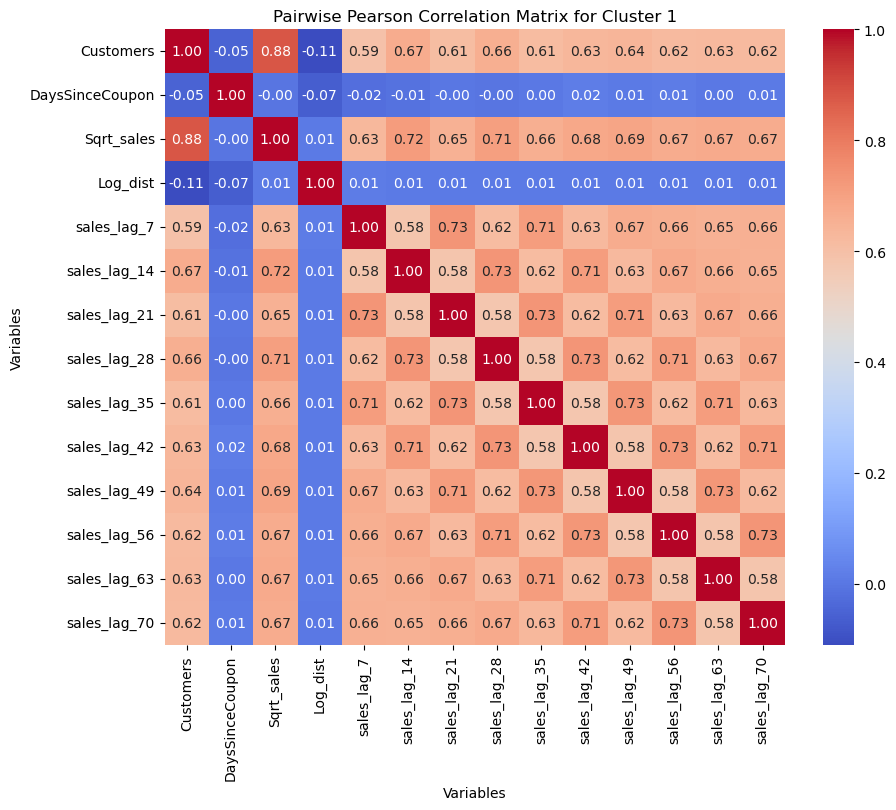

In [127]:
import pandas as pd
import seaborn as sns

# Assuming your DataFrame is named 'df' and contains the variables for which you want to compute correlations

# Compute pairwise Pearson correlation matrix
correlation_matrix = corrmatrix.corr(method='pearson')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Pairwise Pearson Correlation Matrix for Cluster 1")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.show()

Point Biserial test

In [128]:
from scipy.stats import pointbiserialr

# Assuming your DataFrame is named 'df' and contains the binary feature columns and the 'Sales' column

# Iterate over each binary feature column
for column in cat_features.columns:
    # Calculate Point-Biserial correlation coefficient and p-value
    correlation_coefficient, p_value = pointbiserialr(train_cluster1[column], train_cluster1['Sqrt_sales'])
    
    # Print results
    print(f"Point-Biserial Correlation for Cluster 1 {column}: {correlation_coefficient}, p-value: {p_value}")
#Remove Open and Promo

Point-Biserial Correlation for Cluster 1 DayOfWeek: -0.5819243709788662, p-value: 0.0
Point-Biserial Correlation for Cluster 1 Open: 0.9229592295640321, p-value: 0.0
Point-Biserial Correlation for Cluster 1 Promo: 0.4649265522978506, p-value: 0.0
Point-Biserial Correlation for Cluster 1 SchoolHoliday: 0.1086241860533199, p-value: 0.0
Point-Biserial Correlation for Cluster 1 Promo2: -0.008907060546921435, p-value: 1.2250155987826592e-08
Point-Biserial Correlation for Cluster 1 Assortment_a: -0.03904703806339688, p-value: 1.0025809731716607e-137
Point-Biserial Correlation for Cluster 1 Assortment_b: 0.05540363547344939, p-value: 2.1804658396743557e-275
Point-Biserial Correlation for Cluster 1 Assortment_c: 0.028828050976159827, p-value: 6.336347378286126e-76
Point-Biserial Correlation for Cluster 1 StoreType_a: -0.03742954563026292, p-value: 1.0490753154166053e-126
Point-Biserial Correlation for Cluster 1 StoreType_b: 0.06545980747324778, p-value: 0.0
Point-Biserial Correlation for Clust

In [45]:
features.columns
features = features.drop(columns = ['StoreType_c'])

# Cross-validation for ML models

0. Baseline model

In [56]:
#MSE of baseline model to compare with
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import numpy as np

# Assign 'y_true' as the actual target variable and 'y_pred_mean' as the mean prediction
y_true = train_cluster1['Sqrt_sales'] 
y_pred_mean = np.full_like(y_true, y_true.mean())  # Predicting the mean for every sample

mae_base = mean_absolute_error(y_true, y_pred_mean)
print(f'MAE: {mae_base}')
# Calculate MSE for the mean prediction
mse_base = mean_squared_error(y_true, y_pred_mean)
print(f'Mean Squared Error for Mean Prediction: {mse_base}')


MAE: 21.91557125646731
Mean Squared Error for Mean Prediction: 856.2209931705096


1. Lagged sales

In [52]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error

In [54]:
#Linear Regression on logged sales
# Define the number of splits for time series cross-validation
num_splits = 5

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=num_splits)

# Initialize linear regression model
model = LinearRegression()

X = features
y = train_cluster1['Sqrt_sales']
        
# Perform time series cross-validation and get MAE scores for each split
mae_scores = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=tscv)
# Display the mean of mean squared error scores
mae_linear_scaled = -np.mean(mae_scores)
print(f'MAE Scores for Linear Regression: {mae_linear_scaled}')
    
# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Calculate and print the mean MSE score
mean_mse_linear = -np.mean(mse_scores)
# Display the mean of mean squared error scores
print(f'MSE Scores for Linear Regression with raw data: {mean_mse_linear}')

# Perform time series cross-validation and get R-squared scores for each split
r2_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean R-squared score
mean_r2_linear = np.mean(r2_scores)
# Display the mean of R2 scores
print(f'R2 Scores for Linear Regression with raw data: {mean_r2_linear}')

MAE Scores for Linear Regression: 4.706660627614975
MSE Scores for Linear Regression with raw data: 46.69972371956199
R2 Scores for Linear Regression with raw data: 0.9453092009029463


In [55]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

#Random Forest with raw data 

# Define the number of splits for time series cross-validation
num_splits = 5

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=num_splits)

# Initialize Random Forest Regressor model
model = MLPRegressor(hidden_layer_sizes=(10, 5), activation='relu', solver='adam', max_iter=100)

X = features
y = train_cluster1['Sqrt_sales']

# Perform time series cross-validation and get MAE scores for each split
mae_scores = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=tscv)
# Calculate and print the mean MAE score
mean_mae_RF = -np.mean(mae_scores)
# Display the mean of MSE scores
print(f'MAE Scores for RF with raw data: {mean_mae_RF}')

# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Calculate and print the mean MSE score
mean_mse_RF = -np.mean(mse_scores)
# Display the mean of MSE scores
print(f'MSE Scores for RF with raw data: {mean_mse_RF}')

# Perform time series cross-validation and get R-squared scores for each split
r2_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean R-squared score
mean_r2_RF = np.mean(r2_scores)
# Display the mean of R2 scores
print(f'Mean of R2 Scores for RF: {mean_r2_RF}')

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


MAE Scores for RF with raw data: 10.232836494886625


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


MSE Scores for RF with raw data: 86.84649637504927


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Mean of R2 Scores for RF: 0.579200654200873


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


1.1. Lagged features with scaling 

2. Log_sales

# Using Linear model for prediction

3.2. Predict using linear model

In [129]:
#Use the Linear Regression model on raw data with 14 lagged sales and offer
#Set Train data
X_train = features
y_train = train_cluster1['Sqrt_sales']
        
# Initialize a model
final_model = MLPRegressor(hidden_layer_sizes=(10, 5), activation='relu', solver='adam', max_iter=100)

# Train the model on the historical data from 2016
final_model.fit(X_train, y_train)

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(10, 5), max_iter=100)

In [73]:
test = pd.read_csv('test_model.csv', parse_dates = ['Date'], dayfirst=True, low_memory = False)
test = test.drop(columns = "Unnamed: 0")
test.set_index('Date', inplace=True)

In [74]:
test_cluster = test[test['Cluster'] == 1]

In [75]:
test_cluster.columns
test_cluster = test_cluster.drop(columns = ['Sales','Customers','Competitionsincedate','WeeksSinceLastCompOpen','Promosincedate',
       'WeeksSinceLastPromo','Cluster','LastCouponSend'])
test_cluster['StateHoliday_b'] = 0
test_cluster['StateHoliday_c'] = 0
test_cluster['Log_dist'] = np.log(test_cluster['CompetitionDistance'])

C:\Users\PC\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [76]:
features.columns

Index(['DayOfWeek', 'Open', 'Promo', 'SchoolHoliday', 'Promo2', 'Assortment_a',
       'Assortment_b', 'Assortment_c', 'StoreType_a', 'StoreType_b',
       'StoreType_d', 'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b',
       'StateHoliday_c', 'DaysSinceCoupon', 'Log_dist', 'sales_lag_7',
       'sales_lag_14', 'sales_lag_21', 'sales_lag_28', 'sales_lag_35',
       'sales_lag_42', 'sales_lag_49', 'sales_lag_56', 'sales_lag_63',
       'sales_lag_70'],
      dtype='object')

In [77]:
test_features = test_cluster.drop(columns = 'CompetitionDistance')

In [78]:
train_cluster1['Store'] = train_cluster1['Store'].astype(int)

In [79]:
cluster_tomerge = train_cluster1.iloc[:,[0,1,2]]
# Filter train_df to include data from 70 days before 31/7/2015
start_date_train = pd.to_datetime('2015-05-22')  # 70 days before 31/7/2015
train_df_filtered = cluster_tomerge[cluster_tomerge.index >= start_date_train]

# Concatenate train and test datasets vertically
combined_df = pd.concat([train_df_filtered, test_features], axis=0)


In [80]:
combined_df['Date']=combined_df.index

In [101]:
combined_df[combined_df['Store'] == 209]

,Store,DayOfWeek,Sales,Open,Promo,SchoolHoliday,Promo2,Assortment_a,Assortment_b,Assortment_c,...,StoreType_b,StoreType_c,StoreType_d,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c,DaysSinceCoupon,Log_dist,Date
Date,,,,,,,,,,,,,,,,,,,,,
2015-05-22,209,5.0,6153.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,2015-05-22
2015-05-23,209,6.0,5453.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,2015-05-23
2015-05-24,209,7.0,1697.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,2015-05-24
2015-05-25,209,1.0,1691.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,2015-05-25
2015-05-26,209,2.0,6688.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,2015-05-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-09-13,209,7.0,NaN,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,74,9.365633,2015-09-13
2015-09-14,209,1.0,NaN,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,75,9.365633,2015-09-14
2015-09-15,209,2.0,NaN,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,76,9.365633,2015-09-15


In [82]:
combined_df = combined_df[['Store', 'DayOfWeek', 'Sales', 'Open', 'Promo', 'SchoolHoliday',
       'Promo2', 'Assortment_a', 'Assortment_b',
       'Assortment_c', 'StoreType_a', 'StoreType_b', 'StoreType_c',
       'StoreType_d', 'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b',
       'StateHoliday_c','DaysSinceCoupon','Log_dist', 'Date']]

In [83]:
combined_df['DaysSinceCoupon']=combined_df['DaysSinceCoupon'].fillna(0).astype(int)

In [86]:
import random
# Extract unique store numbers from the "Store" column
unique_store_numbers = test_features['Store'].unique()

# Choose 2 random store numbers
random_store_numbers = random.sample(list(unique_store_numbers), 2)

# Now 'random_store_numbers' contains 2 randomly chosen store numbers from the "Store" column
print("Randomly chosen store numbers:", random_store_numbers)

Randomly chosen store numbers: [410, 209]


In [87]:
test_0 = test_features.copy()

# List to store subsets with lagged features
lagged_subsets = []

for store in random_store_numbers:
    # Filter data for the current product and store
    condition = (combined_df['Store'] == store)
    subset = combined_df.loc[condition].copy()
        
    lagged_subsets.append(subset)

In [88]:
lagged_subsets

[            Store  DayOfWeek   Sales  Open  Promo  SchoolHoliday  Promo2  \
 Date                                                                       
 2015-05-22    410        5.0  7782.0   NaN    NaN            NaN     NaN   
 2015-05-23    410        6.0  5959.0   NaN    NaN            NaN     NaN   
 2015-05-24    410        7.0     0.0   NaN    NaN            NaN     NaN   
 2015-05-25    410        1.0     0.0   NaN    NaN            NaN     NaN   
 2015-05-26    410        2.0  6049.0   NaN    NaN            NaN     NaN   
 ...           ...        ...     ...   ...    ...            ...     ...   
 2015-09-13    410        7.0     NaN   0.0    0.0            0.0     1.0   
 2015-09-14    410        1.0     NaN   1.0    1.0            0.0     1.0   
 2015-09-15    410        2.0     NaN   1.0    1.0            0.0     1.0   
 2015-09-16    410        3.0     NaN   1.0    1.0            0.0     1.0   
 2015-09-17    410        4.0     NaN   1.0    1.0            0.0     1.0   

In [130]:
# Specify the date range for training and testing
start_date_test = pd.to_datetime('2015-08-01')
end_date_test = pd.to_datetime('2015-09-17')

predicted_sales = []

for subset in (lagged_subsets):
    # Initialize test_data once for the entire subset
    subset_test = subset.copy()

    for day in pd.date_range(start=start_date_test, end=end_date_test):
        test_data = subset_test[subset_test['Date'] <= day].copy()
        # Create lagged sales features for each week up to 10 weeks ago
        num_weeks = 10
        for i in range(1, num_weeks + 1):
            lagged_sales_col = f'sales_lag_{i * 7}'  # Create column name for lagged sales
            test_data[lagged_sales_col] = test_data['Sales'].shift(i * 7)  # Shift sales by multiples of 7 days

        # Drop rows with NaN values resulting from lagged shifting
        test_data = test_data.fillna(0)

        #Make X_test
        x = test_data.drop(['Sales','Store','StoreType_c'],axis=1)
        X_test = x[x['Date'] == day].drop('Date',axis = 1)
        
        #Initiate the predictions
        predictions = final_model.predict(X_test)

        #Update the subset
        subset_test.loc[subset['Date'] == day, 'Sales'] = predictions**2
    
    #Retain the only part from 31/07/2017 onward
    subset_test = subset_test[subset_test['Date'] >= start_date_test]
    # Replace the old subset with the updated one in lagged_subsets
    predicted_sales.append(subset_test)

In [131]:
store209_forecasted = predicted_sales[1]
store209_forecasted

,Store,DayOfWeek,Sales,Open,Promo,SchoolHoliday,Promo2,Assortment_a,Assortment_b,Assortment_c,...,StoreType_b,StoreType_c,StoreType_d,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c,DaysSinceCoupon,Log_dist,Date
Date,,,,,,,,,,,,,,,,,,,,,
2015-08-01,209,6.0,4467.612335,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,31,9.365633,2015-08-01
2015-08-02,209,7.0,2799.809089,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,32,9.365633,2015-08-02
2015-08-03,209,1.0,8551.863866,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,33,9.365633,2015-08-03
2015-08-04,209,2.0,6612.238789,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,34,9.365633,2015-08-04
2015-08-05,209,3.0,6441.085100,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,35,9.365633,2015-08-05
2015-08-06,209,4.0,7420.673071,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,36,9.365633,2015-08-06
2015-08-07,209,5.0,7077.506214,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,37,9.365633,2015-08-07
2015-08-08,209,6.0,4161.687209,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,38,9.365633,2015-08-08
2015-08-09,209,7.0,2886.025110,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,39,9.365633,2015-08-09


In [132]:
store209 = train_cluster1[train_cluster1['Store'] == 209]
store209 = store209[store209['Sales'] > 0]

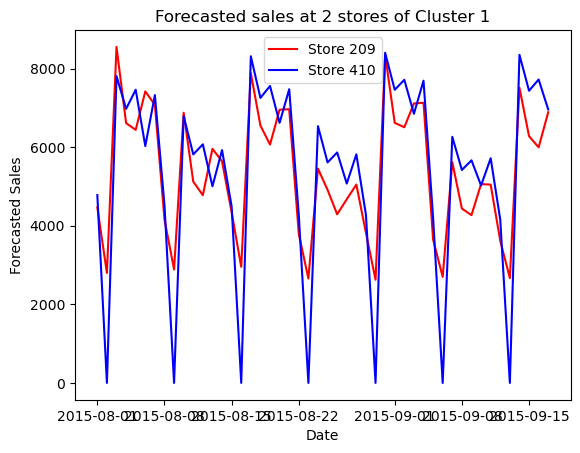

In [133]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_actual is your DataFrame containing the actual sales data
# Assuming df_forecast is your DataFrame containing the forecasted sales for the next 15 days

# Plot forecasted sales data
plt.plot(store209_forecasted['Sales'], label='Store 209', color='red')
plt.plot(store410['Sales'], label='Store 410', color='blue')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Forecasted Sales')
plt.title('Forecasted sales at 2 stores of Cluster 1')
plt.legend()
# Show plot
plt.show()

In [120]:
store410 = predicted_sales[0]
# Replace negative sales values with 0
store410.loc[store410['Sales'] < 1, 'Sales'] = 0


In [153]:
subset_test

,Store,DayOfWeek,Sales,Open,Promo,SchoolHoliday,Promo2,Assortment_a,Assortment_b,Assortment_c,...,StoreType_b,StoreType_c,StoreType_d,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c,DaysSinceCoupon,Log_dist,Date
Date,,,,,,,,,,,,,,,,,,,,,
2015-08-01,7,6.0,78.650502,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-08-01
2015-08-02,7,7.0,-1.262113,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-08-02
2015-08-03,7,1.0,109.678398,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-08-03
2015-08-04,7,2.0,106.414673,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-08-04
2015-08-05,7,3.0,101.750777,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-08-05
2015-08-06,7,4.0,104.098844,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-08-06
2015-08-07,7,5.0,107.661549,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-08-07
2015-08-08,7,6.0,74.401451,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-08-08
2015-08-09,7,7.0,-1.262888,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-08-09


In [131]:
subset_test = lagged_subsets[1].copy()
subset_test[subset_test['Date'] >= '2015-08-06']

,Store,DayOfWeek,Sales,Open,Promo,SchoolHoliday,Promo2,Assortment_a,Assortment_b,Assortment_c,...,StoreType_b,StoreType_c,StoreType_d,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c,DaysSinceCoupon,Log_dist,Date
Date,,,,,,,,,,,,,,,,,,,,,
2015-08-08,7,6.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-08-08
2015-09-08,7,7.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-09-08
2015-10-08,7,1.0,NaN,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-10-08
2015-11-08,7,2.0,NaN,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-11-08
2015-12-08,7,3.0,NaN,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-12-08
2015-08-13,7,4.0,NaN,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-08-13
2015-08-14,7,5.0,NaN,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-08-14
2015-08-15,7,6.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-08-15
2015-08-16,7,7.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-08-16


In [130]:
subset_test.tail(50)

,Store,DayOfWeek,Sales,Open,Promo,SchoolHoliday,Promo2,Assortment_a,Assortment_b,Assortment_c,...,StoreType_b,StoreType_c,StoreType_d,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c,DaysSinceCoupon,Log_dist,Date
Date,,,,,,,,,,,,,,,,,,,,,
2015-07-30,7,4.0,11560.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,2015-07-30
2015-07-31,7,5.0,15344.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,2015-07-31
2015-01-08,7,6.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-01-08
2015-02-08,7,7.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-02-08
2015-03-08,7,1.0,NaN,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-03-08
2015-04-08,7,2.0,NaN,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-04-08
2015-05-08,7,3.0,NaN,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-05-08
2015-06-08,7,4.0,NaN,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-06-08
2015-07-08,7,5.0,NaN,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,10.085809,2015-07-08
